In [30]:
%pip install matplotlib
%pip install seaborn
%pip install xgboost


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [31]:
# XGBoost Anomaly Detection on AnoShift Dataset

## 1. Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import xgboost as xgb
import time
import os
import sys

# Set random seed for reproducibility
np.random.seed(42)

In [54]:
## 2. Load and Preprocess the AnoShift Dataset
# Using the provided loading and preprocessing functions

# train_years = [2006, 2007, 2008, 2009, 2010]
# test_years = [2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015]

# train_years = [2006]
# test_years = [2006]

train_years = [2006, 2007, 2008]
test_years = [2009, 2010, 2011, 2012, 2013, 2014, 2015]

In [55]:
def load_train_year(anoshift_db_path, year):
    if year <= 2010:
        df = pd.read_parquet(os.path.join(anoshift_db_path, f'subset/{year}_subset.parquet'))
    else:
        sys.exit(-1)
    df = df.reset_index(drop=True)

    print(f"Loading {year} subset for train", df)
    return df

def load_test_year(anoshift_db_path, year):
    if year <= 2010:
        df = pd.read_parquet(os.path.join(anoshift_db_path, f'subset/{year}_subset_valid.parquet'))
    else:
        df = pd.read_parquet(os.path.join(anoshift_db_path, f'subset/{year}_subset.parquet'))
    df = df.reset_index(drop=True)
    
    print(f"Loading {year} subset for test", df)
    return df 

In [56]:
def rename_columns(df):
    categorical_cols = ["0", "1", "2", "3", "13"]
    numerical_cols = ["4", "5", "6", "7", "8", "9", "10", "11", "12"]
    additional_cols = ["14", "15", "16", "17", "19"]
    label_col = ["18"]

    new_names = []
    for col_name in df.columns.values:
        if col_name in numerical_cols:
            df[col_name] = pd.to_numeric(df[col_name])
            new_names.append((col_name, "num_" + col_name))
        elif col_name in categorical_cols:
            new_names.append((col_name, "cat_" + col_name))
        elif col_name in additional_cols:
            new_names.append((col_name, "bonus_" + col_name))
        elif col_name in label_col:
            df[col_name] = pd.to_numeric(df[col_name])
            new_names.append((col_name, "label"))
        else:
            new_names.append((col_name, col_name))
    df.rename(columns=dict(new_names), inplace=True)

    print("Renamed columns:", df)

    return df

In [57]:
def preprocess(df, enc=None):
    if not enc:
        enc = OneHotEncoder(handle_unknown='ignore')
        enc.fit(df.loc[:,['cat_' in i for i in df.columns]])
    
    num_cat_features = enc.transform(df.loc[:,['cat_' in i for i in df.columns]]).toarray()

    df_catnum = pd.DataFrame(num_cat_features)
    df_catnum = df_catnum.add_prefix('catnum_')

    df = df.reset_index(drop=True)
    df_new = pd.concat([df, df_catnum], axis=1)
   
    df_new.loc[df_new['label'] < 0, 'label'] = -1
    df_new['label'].replace({1:0}, inplace=True)
    df_new['label'].replace({-1:1}, inplace=True)

    print(df_new, enc)
    
    return df_new, enc

In [58]:
def get_train(anoshift_db_path, train_data_percent=1):
    dfs = []

    for year in train_years: 
        df_year = load_train_year(anoshift_db_path, year)
        dfs.append(df_year)
    
    df_all_years = pd.concat(dfs, ignore_index=True)
    df_all_years = rename_columns(df_all_years)
    df_new, ohe_enc = preprocess(df_all_years)    

    # Get all feature columns (numerical and one-hot encoded categorical)
    feature_cols = [col for col in df_new.columns if col.startswith('num_') or col.startswith('catnum_')]
    
    # Sample a fraction of data if requested
    df_sampled = df_new.sample(frac=train_data_percent)
    
    # Extract features and labels for both normal and anomalous samples
    X_train = df_sampled[feature_cols].to_numpy()
    y_train = df_sampled['label'].to_numpy()
    
    # Calculate statistics (can still be based on normal samples only if preferred)
    normal_samples = df_sampled[df_sampled['label'] == 0]
    normal_features = normal_samples[feature_cols].to_numpy()
    data_mean = normal_features.mean(0)[None,:]
    data_std = normal_features.std(0)[None,:]
    data_std[data_std==0] = 1

    return X_train, y_train, ohe_enc, data_mean, data_std, df_new

def get_n_test_splits():
    return len(test_years)

# def get_test(anoshift_db_path, idx, ohe_enc):
#     year = test_years[idx]
    
#     df_year = load_test_year(anoshift_db_path, year)
#     df_year = rename_columns(df_year)
#     df_test, _ = preprocess(df_year, ohe_enc)
#     numerical_cols = df_test.columns.to_numpy()[['num_' in i for i in df_test.columns]]
#     X_test = df_test[numerical_cols].to_numpy()
#     y_test = df_test["label"].to_numpy()

#     X_test = np.nan_to_num(X_test)

#     print("X_test shape:", X_test)
#     print("y_test shape:", y_test)
#     print("df_test shape:", df_test)
 
#     return X_test, y_test, df_test

def get_test(anoshift_db_path, idx, ohe_enc):
    year = test_years[idx]
    
    df_year = load_test_year(anoshift_db_path, year)
    df_year = rename_columns(df_year)
    df_test, _ = preprocess(df_year, ohe_enc)
    
    # Use the same feature selection approach as get_train()
    feature_cols = [col for col in df_test.columns if col.startswith('num_') or col.startswith('catnum_')]
    X_test = df_test[feature_cols].to_numpy()
    y_test = df_test["label"].to_numpy()

    X_test = np.nan_to_num(X_test)

    print("X_test shape:", X_test.shape)  # Changed to print shape, not the array itself
    print("y_test shape:", y_test.shape)  # Changed to print shape
    print("df_test shape:", df_test.shape)  # Changed to print shape
 
    return X_test, y_test, df_test

In [59]:
## 3. Load AnoShift Dataset
# Set the path to the AnoShift database
anoshift_db_path = '/Users/sakshamaggarwal/Documents/Git_Repos/cybersec_research/AnoShift-RIT/datasets/Kyoto-2016_AnoShift/'  # Change this to your AnoShift database path

In [60]:
# Function to check if the path exists
def check_anoshift_path(path):
    if not os.path.exists(path):
        print(f"ERROR: AnoShift database path '{path}' does not exist.")
        print("Please set the correct path to the AnoShift database.")
        return False
    
    print(f"INFO: AnoShift database path '{path}' exists.")
    return True

In [61]:
# Load and preprocess the training data
def load_and_preprocess_data(anoshift_db_path):
    if not check_anoshift_path(anoshift_db_path):
        return None, None, None, None, None
    
    try:
        print("Loading and preprocessing AnoShift training data...")
        X_train_iso, y_train_iso, ohe_enc, data_mean, data_std, df_train = get_train(anoshift_db_path)
        
        # Extract features for XGBoost (including both numerical and one-hot encoded categorical features)
        feature_cols = [col for col in df_train.columns if col.startswith('num_') or col.startswith('catnum_')]
        
        # Split data into training and validation sets (80/20 split)
        from sklearn.model_selection import train_test_split
        
        # Use stratified sampling to maintain class distribution
        train_df, val_df = train_test_split(df_train, test_size=0.2, random_state=42, stratify=df_train['label'])
        # train_df = df_train
        # val_df = df_train
        
        # Create proper training set with both normal and abnormal samples
        X_train_all = train_df[feature_cols]
        y_train = train_df["label"].values
        
        # Create validation set
        X_val = val_df[feature_cols]
        y_val = val_df["label"].values
        
        print(f"Training data shape: {X_train_all.shape}")
        print(f"Training labels distribution: Normal: {(y_train == 0).sum()}, Abnormal: {(y_train == 1).sum()}")
        print(f"Anomaly percentage in training: {100 * y_train.mean():.2f}%")
        
        print(f"Validation data shape: {X_val.shape}")
        print(f"Validation labels distribution: Normal: {(y_val == 0).sum()}, Abnormal: {(y_val == 1).sum()}")
        print(f"Anomaly percentage in validation: {100 * y_val.mean():.2f}%")
        
        return X_train_all, y_train, X_val, y_val, ohe_enc
    
    except Exception as e:
        print(f"Error loading AnoShift dataset: {str(e)}")
        return None, None, None, None, None

In [62]:
# Load first test split for evaluation
def load_test_data(anoshift_db_path, ohe_enc, test_idx=0):
    if not check_anoshift_path(anoshift_db_path):
        return None, None, None
    
    try:
        print(f"Loading test data for year {test_years[test_idx]}...")
        X_test, y_test, df_test = get_test(anoshift_db_path, test_idx, ohe_enc)
        
        # Get feature columns (both numerical and one-hot encoded)
        feature_cols = [col for col in df_test.columns if col.startswith('num_') or col.startswith('catnum_')]
        
        # Extract proper feature set
        X_test_all = df_test[feature_cols]
        
        print(f"Test data shape: {X_test_all.shape}")
        print(f"Anomaly percentage in test: {100 * y_test.mean():.2f}%")
        
        return X_test_all, y_test, df_test
    
    except Exception as e:
        print(f"Error loading test data: {str(e)}")
        return None, None, None

In [ ]:
# Load the data
X_train, y_train, X_val, y_val, ohe_enc = load_and_preprocess_data(anoshift_db_path)

INFO: AnoShift database path '/Users/sakshamaggarwal/Documents/Git_Repos/cybersec_research/AnoShift-RIT/datasets/Kyoto-2016_AnoShift/' exists.
Loading and preprocessing AnoShift training data...
Loading 2006 subset for train            0      1     2     3   4    5     6     7   8    9    10   11  \
0       c015  other   c20   c30   4  1.0   1.0   0.8  90  100   0.0  1.0   
1        c00  other   c20   c30   0  0.0   0.0   0.0   6   80  0.83  0.0   
2       c021   smtp  c274  c357   2  1.0   0.0   0.0   7   97   0.0  0.0   
3        c07   smtp  c274  c357  22  1.0   0.0   0.0  17   95   0.0  0.0   
4       c068   smtp  c220  c342   0  0.0   0.0   0.0   1   35   0.0  0.0   
...      ...    ...   ...   ...  ..  ...   ...   ...  ..  ...   ...  ...   
466769  c014  other   c20   c30   5  1.0   0.8   0.5   0  100   0.0  0.0   
466770   c04  other  c238  c338  34  1.0  0.32  0.33   0   58   0.0  0.0   
466771   c03  other  c245  c341   3  1.0   0.0   0.0  42   42   0.0  0.0   
466772  c014  o

In [47]:
def build_xgboost_model(X_train, y_train, X_val, y_val):
    if X_train is None or X_val is None:
        return None
    
    # Calculate class weights to handle imbalance based on training data
    normal_count = np.sum(y_train == 0)
    anomaly_count = np.sum(y_train == 1)
    
    if anomaly_count > 0:
        scale_pos_weight = normal_count / anomaly_count
    else:
        scale_pos_weight = 100  # Default if no anomalies in training
    
    print(f"Class imbalance ratio (normal:anomaly): {scale_pos_weight:.2f}")
    print(f"Training data contains {normal_count} normal samples and {anomaly_count} anomalies")

    # Calculate class weights to handle imbalance based on training data
    normal_count_val = np.sum(y_val == 0)
    anomaly_count_val = np.sum(y_val == 1)
    print(f"Validation data contains {normal_count_val} normal samples and {anomaly_count_val} anomalies")
    
    # Create DMatrix for XGBoost
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    
    # Set parameters - optimized for imbalanced binary classification
    params = {
        'objective': 'binary:logistic',
        'eval_metric': ['auc', 'logloss', 'error'],
        'scale_pos_weight': scale_pos_weight,
        'max_depth': 6,
        'eta': 0.1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'min_child_weight': 1,
        'gamma': 0.1,  # Minimum loss reduction for further partition
        'gpu_id': -1,  # Set to appropriate GPU ID if available, -1 for CPU
        'tree_method': 'hist'  # Use 'gpu_hist' for GPU
    }
    
    # Set evaluation list
    evallist = [(dtrain, 'train'), (dval, 'validation')]
    
    # Train model
    print("Training XGBoost model for supervised anomaly detection...")
    start_time = time.time()
    
    model = xgb.train(
        params,
        dtrain,
        num_boost_round=500,
        evals=evallist,
        early_stopping_rounds=20,
        verbose_eval=50
    )
    
    training_time = time.time() - start_time
    print(f"Training completed in {training_time:.2f} seconds")
    
    # Basic model statistics
    y_train_pred = model.predict(dtrain)
    train_accuracy = np.mean((y_train_pred > 0.5) == y_train)
    
    y_val_pred = model.predict(dval)
    val_accuracy = np.mean((y_val_pred > 0.5) == y_val)
    
    print(f"Training accuracy: {train_accuracy:.4f}")
    print(f"Validation accuracy: {val_accuracy:.4f}")
    
    return model

In [48]:
xgb_model = build_xgboost_model(X_train, y_train, X_val, y_val)

Class imbalance ratio (normal:anomaly): 1.28
Training data contains 999997 normal samples and 782098 anomalies
Validation data contains 249999 normal samples and 195525 anomalies
Training XGBoost model for supervised anomaly detection...
[0]	train-auc:0.98453	train-logloss:0.61510	train-error:0.05798	validation-auc:0.98467	validation-logloss:0.61503	validation-error:0.05761
[50]	train-auc:0.99661	train-logloss:0.08527	train-error:0.02840	validation-auc:0.99657	validation-logloss:0.08555	validation-error:0.02867
[100]	train-auc:0.99745	train-logloss:0.06763	train-error:0.02439	validation-auc:0.99739	validation-logloss:0.06809	validation-error:0.02472
[150]	train-auc:0.99784	train-logloss:0.06108	train-error:0.02233	validation-auc:0.99778	validation-logloss:0.06162	validation-error:0.02260
[200]	train-auc:0.99808	train-logloss:0.05718	train-error:0.02109	validation-auc:0.99801	validation-logloss:0.05779	validation-error:0.02148
[250]	train-auc:0.99824	train-logloss:0.05456	train-error:0.

In [49]:
## 6. Evaluate Model Performance
def evaluate_model(model, X_val, y_val, X_test, y_test):
    if model is None or X_val is None or X_test is None:
        return None
    
    # Convert to pandas DataFrame if numpy arrays
    if isinstance(X_val, np.ndarray):
        X_val = pd.DataFrame(X_val)
    if isinstance(X_test, np.ndarray):
        X_test = pd.DataFrame(X_test)
    
    # Create DMatrix for validation and test data
    dval = xgb.DMatrix(X_val)
    dtest = xgb.DMatrix(X_test)
    
    # Make predictions
    val_preds = model.predict(dval)
    test_preds = model.predict(dtest)
    
    # Convert probabilities to binary predictions with default threshold
    val_pred_binary = (val_preds > 0.5).astype(int)
    test_pred_binary = (test_preds > 0.5).astype(int)
    
    # Function to calculate and display macro F1 score and class-wise F1 scores
    def calculate_macro_f1(y_true, y_pred, set_name):
        from sklearn.metrics import f1_score
        
        # Calculate F1 score with macro averaging
        macro_f1 = f1_score(y_true, y_pred, average='macro')
        
        # Calculate class-wise F1 scores
        class_0_f1 = f1_score(y_true, y_pred, pos_label=0, average='binary')
        class_1_f1 = f1_score(y_true, y_pred, pos_label=1, average='binary')
        
        print(f"\n{set_name} F1 Scores:")
        print(f"  Class 0 (Normal) F1 Score: {class_0_f1:.4f}")
        print(f"  Class 1 (Anomaly) F1 Score: {class_1_f1:.4f}")
        print(f"  Macro F1 Score: {macro_f1:.4f}")
        
        return macro_f1, class_0_f1, class_1_f1
    
    # Validation set metrics
    print("Validation Set Results:")
    print(confusion_matrix(y_val, val_pred_binary))
    print(classification_report(y_val, val_pred_binary))
    
    if np.unique(y_val).shape[0] > 1:  # Check if we have both classes
        val_auc = roc_auc_score(y_val, val_preds)
        print(f"Validation AUC: {val_auc:.4f}")
        # Calculate macro F1 for validation set
        val_macro_f1, val_normal_f1, val_anomaly_f1 = calculate_macro_f1(y_val, val_pred_binary, "Validation")
    
    # Test set metrics
    print("\nTest Set Results:")
    print(confusion_matrix(y_test, test_pred_binary))
    print(classification_report(y_test, test_pred_binary))
    
    if np.unique(y_test).shape[0] > 1:  # Check if we have both classes
        test_auc = roc_auc_score(y_test, test_preds)
        print(f"Test AUC: {test_auc:.4f}")
        # Calculate macro F1 for test set
        test_macro_f1, test_normal_f1, test_anomaly_f1 = calculate_macro_f1(y_test, test_pred_binary, "Test")
    
    # Plot ROC and Precision-Recall curves
    # plt.figure(figsize=(15, 12))  # Increased height for additional subplot
    
    # # If we have both classes in validation set
    # if np.unique(y_val).shape[0] > 1:
    #     # Precision-Recall curve for validation
    #     plt.subplot(221)
    #     precision, recall, _ = precision_recall_curve(y_val, val_preds)
    #     pr_auc = auc(recall, precision)
    #     plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.4f}')
    #     plt.xlabel('Recall')
    #     plt.ylabel('Precision')
    #     plt.title('Validation Precision-Recall Curve')
    #     plt.legend()
    #     plt.grid(True)
    
    # # If we have both classes in test set
    # if np.unique(y_test).shape[0] > 1:
    #     # Precision-Recall curve for test
    #     plt.subplot(222)
    #     precision, recall, _ = precision_recall_curve(y_test, test_preds)
    #     pr_auc = auc(recall, precision)
    #     plt.plot(recall, precision, label=f'PR AUC = {pr_auc:.4f}')
    #     plt.xlabel('Recall')
    #     plt.ylabel('Precision')
    #     plt.title('Test Precision-Recall Curve')
    #     plt.legend()
    #     plt.grid(True)
        
    #     # Add F1 score visualization
    #     plt.subplot(223)
    #     # Bar chart of F1 scores
    #     f1_scores = {
    #         'Normal (Val)': val_normal_f1,
    #         'Anomaly (Val)': val_anomaly_f1,
    #         'Macro (Val)': val_macro_f1,
    #         'Normal (Test)': test_normal_f1,
    #         'Anomaly (Test)': test_anomaly_f1,
    #         'Macro (Test)': test_macro_f1
    #     }
        
    #     x = range(len(f1_scores))
    #     plt.bar(x, f1_scores.values())
    #     plt.xticks(x, f1_scores.keys(), rotation=45)
    #     plt.ylabel('F1 Score')
    #     plt.title('F1 Scores Comparison')
        
    #     # Add prediction distribution
    #     plt.subplot(224)
    #     plt.hist(test_preds[y_test==0], bins=30, alpha=0.5, label='Normal', density=True)
    #     plt.hist(test_preds[y_test==1], bins=30, alpha=0.5, label='Anomaly', density=True)
    #     plt.axvline(x=0.5, color='r', linestyle='--', label='Default Threshold')
    #     plt.xlabel('Prediction Score')
    #     plt.ylabel('Density')
    #     plt.title('Test Prediction Distribution')
    #     plt.legend()
    
    # plt.tight_layout()
    # plt.show()
    
    # Store evaluation metrics
    eval_metrics = {
        'threshold': 0.5,  # Default threshold
        'test_auc': test_auc if np.unique(y_test).shape[0] > 1 else None,
        'test_macro_f1': test_macro_f1 if np.unique(y_test).shape[0] > 1 else None,
        'test_normal_f1': test_normal_f1 if np.unique(y_test).shape[0] > 1 else None,
        'test_anomaly_f1': test_anomaly_f1 if np.unique(y_test).shape[0] > 1 else None
    }
    
    return test_preds, eval_metrics

In [50]:
X_test, y_test, df_test = load_test_data(anoshift_db_path, ohe_enc)
test_predictions, _ = evaluate_model(xgb_model, X_val, y_val, X_test, y_test)

INFO: AnoShift database path '/Users/sakshamaggarwal/Documents/Git_Repos/cybersec_research/AnoShift-RIT/datasets/Kyoto-2016_AnoShift/' exists.
Loading test data for year 2011...
Loading 2011 subset for test             0      1     2     3   4    5    6     7   8   9    10   11   12  \
0        c045   smtp  c280  c372   2  1.0  0.0   0.0   0  58   0.0  0.0  0.0   
1        c015   smtp  c248  c364   0  0.0  0.0   0.0   2  84   0.0  0.0  0.0   
2        c010   smtp  c274  c366   1  1.0  0.0   0.0   3  76   0.0  0.0  0.0   
3        c016   smtp  c293  c376   1  1.0  0.0   0.0   0  71   0.0  0.0  0.0   
4        c040   smtp  c273  c373   0  0.0  0.0   0.0   0  42   0.0  0.0  0.0   
...       ...    ...   ...   ...  ..  ...  ...   ...  ..  ..   ...  ...  ...   
1119242   c08  other   c20   c30   0  0.0  0.0  0.86  24  24   0.0  0.0  0.0   
1119243   c00  other   c20   c30  15  1.0  0.0  0.05  22  86  0.05  0.0  0.0   
1119244  c010  other  c281  c381   2  1.0  0.0  0.17  37  37   0.0  0.0  

/var/folders/zc/6_ry_0zn42760dzx14r53c600000gn/T/ipykernel_60466/2953266764.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_new['label'].replace({1:0}, inplace=True)
/var/folders/zc/6_ry_0zn42760dzx14r53c600000gn/T/ipykernel_60466/2953266764.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

        cat_0  cat_1 cat_2 cat_3  num_4  num_5  num_6  num_7  num_8  num_9  \
0        c045   smtp  c280  c372      2    1.0    0.0   0.00      0     58   
1        c015   smtp  c248  c364      0    0.0    0.0   0.00      2     84   
2        c010   smtp  c274  c366      1    1.0    0.0   0.00      3     76   
3        c016   smtp  c293  c376      1    1.0    0.0   0.00      0     71   
4        c040   smtp  c273  c373      0    0.0    0.0   0.00      0     42   
...       ...    ...   ...   ...    ...    ...    ...    ...    ...    ...   
1119242   c08  other   c20   c30      0    0.0    0.0   0.86     24     24   
1119243   c00  other   c20   c30     15    1.0    0.0   0.05     22     86   
1119244  c010  other  c281  c381      2    1.0    0.0   0.17     37     37   
1119245   c07  other  c250  c356     13    1.0    0.0   0.06     10     93   
1119246   c00  other   c20   c30     16    1.0    0.0   0.04     13     76   

         ...  catnum_551  catnum_552  catnum_553 catnum_554 cat

In [ ]:
list_of_test_preds = {}

for idx in range(len(test_years)):
    # Load test data for the current year
    X_test, y_test, df_test = load_test_data(anoshift_db_path, ohe_enc, test_idx=idx)
    
    # Evaluate model on the test data
    print(f"Evaluating model on test data for year {test_years[idx]}...")
    test_predictions, eval_metrics = evaluate_model(xgb_model, X_val, y_val, X_test, y_test)
    
    # Print evaluation metrics
    print(f"Test Predictions for year {test_years[idx]}: {test_predictions}")
    print(f"Evaluation Metrics for year {test_years[idx]}: {eval_metrics}")

    list_of_test_preds[test_years[idx]] = {
        'predictions': test_predictions,
        'metrics': eval_metrics
    }
    print(f"Test predictions for year {test_years[idx]} added to list.")
    print(f"Test predictions list length: {len(list_of_test_preds)}")

INFO: AnoShift database path '/Users/sakshamaggarwal/Documents/Git_Repos/cybersec_research/AnoShift-RIT/datasets/Kyoto-2016_AnoShift/' exists.
Loading test data for year 2011...
Loading 2011 subset for test             0      1     2     3   4    5    6     7   8   9    10   11   12  \
0        c045   smtp  c280  c372   2  1.0  0.0   0.0   0  58   0.0  0.0  0.0   
1        c015   smtp  c248  c364   0  0.0  0.0   0.0   2  84   0.0  0.0  0.0   
2        c010   smtp  c274  c366   1  1.0  0.0   0.0   3  76   0.0  0.0  0.0   
3        c016   smtp  c293  c376   1  1.0  0.0   0.0   0  71   0.0  0.0  0.0   
4        c040   smtp  c273  c373   0  0.0  0.0   0.0   0  42   0.0  0.0  0.0   
...       ...    ...   ...   ...  ..  ...  ...   ...  ..  ..   ...  ...  ...   
1119242   c08  other   c20   c30   0  0.0  0.0  0.86  24  24   0.0  0.0  0.0   
1119243   c00  other   c20   c30  15  1.0  0.0  0.05  22  86  0.05  0.0  0.0   
1119244  c010  other  c281  c381   2  1.0  0.0  0.17  37  37   0.0  0.0  

/var/folders/zc/6_ry_0zn42760dzx14r53c600000gn/T/ipykernel_60466/2953266764.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_new['label'].replace({1:0}, inplace=True)
/var/folders/zc/6_ry_0zn42760dzx14r53c600000gn/T/ipykernel_60466/2953266764.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

        cat_0  cat_1 cat_2 cat_3  num_4  num_5  num_6  num_7  num_8  num_9  \
0        c045   smtp  c280  c372      2    1.0    0.0   0.00      0     58   
1        c015   smtp  c248  c364      0    0.0    0.0   0.00      2     84   
2        c010   smtp  c274  c366      1    1.0    0.0   0.00      3     76   
3        c016   smtp  c293  c376      1    1.0    0.0   0.00      0     71   
4        c040   smtp  c273  c373      0    0.0    0.0   0.00      0     42   
...       ...    ...   ...   ...    ...    ...    ...    ...    ...    ...   
1119242   c08  other   c20   c30      0    0.0    0.0   0.86     24     24   
1119243   c00  other   c20   c30     15    1.0    0.0   0.05     22     86   
1119244  c010  other  c281  c381      2    1.0    0.0   0.17     37     37   
1119245   c07  other  c250  c356     13    1.0    0.0   0.06     10     93   
1119246   c00  other   c20   c30     16    1.0    0.0   0.04     13     76   

         ...  catnum_551  catnum_552  catnum_553 catnum_554 cat

/var/folders/zc/6_ry_0zn42760dzx14r53c600000gn/T/ipykernel_60466/2953266764.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_new['label'].replace({1:0}, inplace=True)
/var/folders/zc/6_ry_0zn42760dzx14r53c600000gn/T/ipykernel_60466/2953266764.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

       cat_0  cat_1 cat_2 cat_3  num_4  num_5  num_6  num_7  num_8  num_9  \
0       c023   smtp  c273  c363      0    0.0    0.0   0.00      2     68   
1       c019   smtp  c277  c369      2    0.5    0.0   0.00      1     55   
2       c025   smtp  c284  c378      0    0.0    0.0   0.00      0     78   
3       c012   smtp  c250  c358      3    1.0    0.0   0.00      2     61   
4       c012   smtp  c274  c365      0    0.0    0.0   0.00      3     57   
...      ...    ...   ...   ...    ...    ...    ...    ...    ...    ...   
934587   c07  other  c250  c356      0    0.0    0.0   0.80      3     21   
934588   c00  other   c20   c30      1    1.0    1.0   0.67     11     47   
934589  c014  other   c20   c30      1    1.0    1.0   1.00      6     33   
934590   c00  other   c20   c30      3    1.0    1.0   0.89      2     32   
934591   c07  other  c250  c356      0    0.0    0.0   1.00      2     40   

        ...  catnum_551  catnum_552  catnum_553 catnum_554 catnum_555  \
0 

...

        cat_0  cat_1 cat_2 cat_3  num_4  num_5  num_6  num_7  num_8  num_9  \
0        c017   smtp  c274  c367      1   1.00   0.00   0.00     14     78   
1         c05    ssh  c267  c377      5   0.60   0.00   0.00     26     26   
2         c08  other   c20   c30      0   0.00   0.00   1.00      0     62   
3        c047  other  c275   c30      0   0.00   0.00   0.83     14     14   
4        c031   smtp  c274  c367      3   0.33   0.33   0.00      0     70   
...       ...    ...   ...   ...    ...    ...    ...    ...    ...    ...   
1538059   c00    dns  c240  c355      5   1.00   0.00   0.17      5     30   
1538060   c00  other   c20   c30      2   1.00   1.00   0.82      3     37   
1538061   c00  other   c20   c30      1   1.00   1.00   0.90     24     58   
1538062  c014  other   c20   c30      0   0.00   0.00   1.00     52     59   
1538063  c014    dns  c247  c357      0   0.00   0.00   0.00      0      0   

         ...  catnum_551  catnum_552  catnum_553 catnum_554 cat

/var/folders/zc/6_ry_0zn42760dzx14r53c600000gn/T/ipykernel_60466/2953266764.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_new['label'].replace({1:0}, inplace=True)
/var/folders/zc/6_ry_0zn42760dzx14r53c600000gn/T/ipykernel_60466/2953266764.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

        cat_0  cat_1 cat_2 cat_3  num_4  num_5  num_6  num_7  num_8  num_9  \
0         c00    dns  c239  c346      1    1.0   1.00   0.33      8     56   
1         c00    dns   c20   c30      8    1.0   0.00   0.05     10     12   
2         c00    dns  c238  c348     58    1.0   0.02   0.09     13     85   
3         c00    dns   c20   c30      6    1.0   0.17   0.26     18     18   
4         c00    dns  c237  c346      8    1.0   0.00   0.00     82     82   
...       ...    ...   ...   ...    ...    ...    ...    ...    ...    ...   
2122657   c00  other   c20   c30      6    1.0   1.00   0.12      1      2   
2122658   c00    dns  c244  c350     10    1.0   0.00   0.14     79     85   
2122659   c00  other   c20   c30     10    1.0   0.10   0.29      4     40   
2122660   c00    dns   c20   c30      3    1.0   1.00   0.57     16     46   
2122661   c00    dns  c243  c350      5    1.0   0.00   0.09     48     84   

         ...  catnum_551  catnum_552  catnum_553 catnum_554 cat

/var/folders/zc/6_ry_0zn42760dzx14r53c600000gn/T/ipykernel_60466/2953266764.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_new['label'].replace({1:0}, inplace=True)
/var/folders/zc/6_ry_0zn42760dzx14r53c600000gn/T/ipykernel_60466/2953266764.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always

        cat_0  cat_1 cat_2 cat_3  num_4  num_5  num_6  num_7  num_8  num_9  \
0         c02    ssh  c265  c377     11   0.18   0.82   0.00     97     97   
1         c00    dns  c239  c348     12   1.00   0.00   0.00     14     93   
2         c00    dns  c241  c356      2   1.00   0.00   0.00      1     24   
3         c00    dns  c239  c346     28   1.00   0.18   0.25     69     69   
4         c00    dns  c240  c349      4   1.00   0.00   0.00     19     79   
...       ...    ...   ...   ...    ...    ...    ...    ...    ...    ...   
2104317  c014  other   c20   c30      1   1.00   1.00   0.56     25     61   
2104318  c014  other   c20   c30      1   1.00   1.00   0.50     48     76   
2104319  c014  other   c20   c30      1   1.00   1.00   0.60     24     94   
2104320  c015  other   c20   c30      5   1.00   1.00   0.70      1     66   
2104321  c030  other   c20   c30      1   0.00   0.00   0.75      2      2   

         ...  catnum_551  catnum_552  catnum_553 catnum_554 cat

In [ ]:
## 8. Anomaly Threshold Analysis
def analyze_anomaly_thresholds(y_test, test_preds):
    if test_preds is None or y_test is None:
        return None, None
    
    threshold = 0.5
    
    # Calculate metrics for each threshold
    results = []
    pred_binary = (test_preds > threshold).astype(int)
    
    # Calculate traditional metrics
    tn, fp, fn, tp = confusion_matrix(y_test, pred_binary, labels=[0,1]).ravel()
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
    
    # Calculate macro F1 score
    from sklearn.metrics import f1_score
    macro_f1 = f1_score(y_test, pred_binary, average='macro')
    
    # Calculate class-wise F1 scores
    normal_f1 = f1_score(y_test, pred_binary, pos_label=0, average='binary')
    anomaly_f1 = f1_score(y_test, pred_binary, pos_label=1, average='binary')
    
    results.append({
        'Threshold': threshold,
        'Precision': precision,
        'Recall': recall,
        'Specificity': specificity,
        'F1': f1,
        'Macro_F1': macro_f1,
        'Normal_F1': normal_f1,
        'Anomaly_F1': anomaly_f1,
        'TP': tp,
        'FP': fp,
        'TN': tn,
        'FN': fn,
        'FPR': fpr,
    })
    
    return results

In [ ]:
list_of_test_preds = {}

for idx in range(len(test_years)):
    # Load test data for the current year
    X_test, y_test, df_test = load_test_data(anoshift_db_path, ohe_enc, test_idx=idx)
    
    # Evaluate model on the test data
    print(f"Evaluating model on test data for year {test_years[idx]}...")
    test_predictions, eval_metrics = evaluate_model(xgb_model, X_val, y_val, X_test, y_test)
    
    # Print evaluation metrics
    print(f"Test Predictions for year {test_years[idx]}: {test_predictions}")
    print(f"Evaluation Metrics for year {test_years[idx]}: {eval_metrics}")

    # Analyze anomaly thresholds
    threshold_results = analyze_anomaly_thresholds(y_test, test_predictions)
    print(f"Threshold Analysis Results for year {test_years[idx]}: {threshold_results}")

    # Write all the above information to a file year-wise.
    with open(f"anoshift_results_{test_years[idx]}.txt", "w") as f:
        f.write(f"Test Predictions for year {test_years[idx]}: {test_predictions}\n")
        f.write(f"Evaluation Metrics for year {test_years[idx]}: {eval_metrics}\n")
        f.write(f"Threshold Analysis Results for year {test_years[idx]}: {threshold_results}\n")

In [51]:
## 7. Feature Importance Analysis
def analyze_feature_importance(model, X_train):
    if model is None or X_train is None:
        return None
    
    # Convert to pandas DataFrame if numpy arrays
    if isinstance(X_train, np.ndarray):
        X_train_df = pd.DataFrame(X_train)
    
    # Get feature names
    feature_names = X_train_df.columns.tolist()
    
    # Get feature importance
    importance_type = 'gain'  # Options: 'weight', 'gain', 'cover', 'total_gain', 'total_cover'
    
    # For new versions of XGBoost
    try:
        importance = model.get_score(importance_type=importance_type)
        
        # Convert to DataFrame for easier handling
        importance_df = pd.DataFrame({
            'Feature': list(importance.keys()),
            'Importance': list(importance.values())
        })
    except:
        # Alternative for newer versions of XGBoost
        importance = model.get_score(fmap='', importance_type=importance_type)
        importance_df = pd.DataFrame({
            'Feature': list(importance.keys()),
            'Importance': list(importance.values())
        })
    
    # Match feature indices with names if needed
    if all(f.isdigit() for f in importance_df['Feature']):
        importance_df['Feature'] = importance_df['Feature'].astype(int).map(
            lambda i: feature_names[i] if i < len(feature_names) else f"Feature_{i}"
        )
    
    importance_df = importance_df.sort_values('Importance', ascending=False)
    
    # Plot top 20 features (or less if fewer features)
    n_top = min(20, importance_df.shape[0])
    plt.figure(figsize=(12, 8))
    sns.barplot(x='Importance', y='Feature', data=importance_df.head(n_top))
    plt.title(f'Top {n_top} Features by Importance')
    plt.tight_layout()
    # plt.show()
    
    # Return feature importance for later use
    return importance_df

In [ ]:
feature_importance = analyze_feature_importance(xgb_model, X_train)

In [ ]:
## 8. Anomaly Threshold Analysis
def analyze_anomaly_thresholds(y_test, test_preds):
    if test_preds is None or y_test is None:
        return None, None
    
    # Generate thresholds
    thresholds = np.linspace(0.01, 0.99, 20)
    
    # Calculate metrics for each threshold
    results = []
    for threshold in thresholds:
        pred_binary = (test_preds > threshold).astype(int)
        
        # Calculate traditional metrics
        tn, fp, fn, tp = confusion_matrix(y_test, pred_binary, labels=[0,1]).ravel()
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0  # False Positive Rate
        
        # Calculate macro F1 score
        from sklearn.metrics import f1_score
        macro_f1 = f1_score(y_test, pred_binary, average='macro')
        
        # Calculate class-wise F1 scores
        normal_f1 = f1_score(y_test, pred_binary, pos_label=0, average='binary')
        anomaly_f1 = f1_score(y_test, pred_binary, pos_label=1, average='binary')
        
        results.append({
            'Threshold': threshold,
            'Precision': precision,
            'Recall': recall,
            'Specificity': specificity,
            'F1': f1,
            'Macro_F1': macro_f1,
            'Normal_F1': normal_f1,
            'Anomaly_F1': anomaly_f1,
            'TP': tp,
            'FP': fp,
            'TN': tn,
            'FN': fn,
            'FPR': fpr,
        })
    
    results_df = pd.DataFrame(results)
    
    # Plot metrics vs threshold
    plt.figure(figsize=(20, 15))
    
    # Traditional metrics
    plt.subplot(321)
    plt.plot(results_df['Threshold'], results_df['Precision'], 'b-', label='Precision')
    plt.plot(results_df['Threshold'], results_df['Recall'], 'g-', label='Recall')
    plt.plot(results_df['Threshold'], results_df['F1'], 'r-', label='F1 Score')
    plt.plot(results_df['Threshold'], results_df['Specificity'], 'm-', label='Specificity')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Traditional Metrics vs Threshold')
    plt.legend()
    plt.grid(True)
    
    # Macro and class-wise F1 scores
    plt.subplot(322)
    plt.plot(results_df['Threshold'], results_df['Macro_F1'], 'k-', label='Macro F1')
    plt.plot(results_df['Threshold'], results_df['Normal_F1'], 'b-', label='Normal F1')
    plt.plot(results_df['Threshold'], results_df['Anomaly_F1'], 'r-', label='Anomaly F1')
    plt.xlabel('Threshold')
    plt.ylabel('F1 Score')
    plt.title('Macro and Class-wise F1 Scores vs Threshold')
    plt.legend()
    plt.grid(True)
    
    # Precision-Recall curve
    plt.subplot(323)
    plt.plot(results_df['Recall'], results_df['Precision'], 'b.-')
    # Annotate some points with threshold values
    for i in range(0, len(thresholds), len(thresholds)//5):
        plt.annotate(f"{thresholds[i]:.2f}", 
                   (results_df['Recall'].iloc[i], results_df['Precision'].iloc[i]),
                   textcoords="offset points", 
                   xytext=(0,10), 
                   ha='center')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve with Thresholds')
    plt.grid(True)
    
    # Classification counts
    plt.subplot(324)
    plt.plot(results_df['Threshold'], results_df['TP'], 'g-', label='True Positives')
    plt.plot(results_df['Threshold'], results_df['FP'], 'r-', label='False Positives')
    plt.plot(results_df['Threshold'], results_df['FN'], 'b-', label='False Negatives')
    plt.xlabel('Threshold')
    plt.ylabel('Count')
    plt.title('Classification Counts vs Threshold')
    plt.legend()
    plt.grid(True)
    
    # ROC curve
    plt.subplot(325)
    plt.plot(results_df['FPR'], results_df['Recall'], 'b.-')
    # Annotate some points with threshold values
    for i in range(0, len(thresholds), len(thresholds)//5):
        plt.annotate(f"{thresholds[i]:.2f}", 
                   (results_df['FPR'].iloc[i], results_df['Recall'].iloc[i]),
                   textcoords="offset points", 
                   xytext=(0,10), 
                   ha='center')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('ROC Curve with Thresholds')
    plt.grid(True)
    
    # Prediction distribution
    plt.subplot(326)
    plt.hist(test_preds[y_test==0], bins=30, alpha=0.5, label='Normal', density=True)
    plt.hist(test_preds[y_test==1], bins=30, alpha=0.5, label='Anomaly', density=True)
    
    # Find both optimal thresholds
    best_f1_idx = results_df['F1'].idxmax()
    best_macro_f1_idx = results_df['Macro_F1'].idxmax()
    
    best_f1_threshold = results_df.loc[best_f1_idx, 'Threshold']
    best_macro_f1_threshold = results_df.loc[best_macro_f1_idx, 'Threshold']
    
    # Add vertical lines for optimal thresholds
    plt.axvline(x=best_f1_threshold, color='r', linestyle='--', 
                label=f'Best F1: {best_f1_threshold:.2f}')
    plt.axvline(x=best_macro_f1_threshold, color='g', linestyle='--', 
                label=f'Best Macro F1: {best_macro_f1_threshold:.2f}')
    
    plt.xlabel('Prediction Score')
    plt.ylabel('Density')
    plt.title('Prediction Distribution with Optimal Thresholds')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Find optimal threshold based on standard F1 score
    if results_df['F1'].max() > 0:
        best_idx = results_df['F1'].idxmax()
        best_threshold = results_df.loc[best_idx, 'Threshold']
        best_f1 = results_df.loc[best_idx, 'F1']
        print(f"Optimal threshold (standard F1): {best_threshold:.2f} (F1: {best_f1:.4f})")
    else:
        # If F1 is 0 for all thresholds, choose a conservative threshold
        best_threshold = 0.95
        print(f"All standard F1 scores are 0. Using conservative threshold: {best_threshold:.2f}")
    
    # Find optimal threshold based on macro F1 score
    if results_df['Macro_F1'].max() > 0:
        best_macro_idx = results_df['Macro_F1'].idxmax()
        best_macro_threshold = results_df.loc[best_macro_idx, 'Threshold']
        best_macro_f1 = results_df.loc[best_macro_idx, 'Macro_F1']
        print(f"Optimal threshold (macro F1): {best_macro_threshold:.2f} (Macro F1: {best_macro_f1:.4f})")
        
        # Show class-wise F1 scores at this threshold
        normal_f1 = results_df.loc[best_macro_idx, 'Normal_F1']
        anomaly_f1 = results_df.loc[best_macro_idx, 'Anomaly_F1']
        print(f"  Class 0 (Normal) F1 at this threshold: {normal_f1:.4f}")
        print(f"  Class 1 (Anomaly) F1 at this threshold: {anomaly_f1:.4f}")
    else:
        best_macro_threshold = best_threshold
        print(f"All macro F1 scores are 0. Using standard F1 threshold: {best_threshold:.2f}")
    
    # Return both thresholds and results
    return best_threshold, best_macro_threshold, results_df

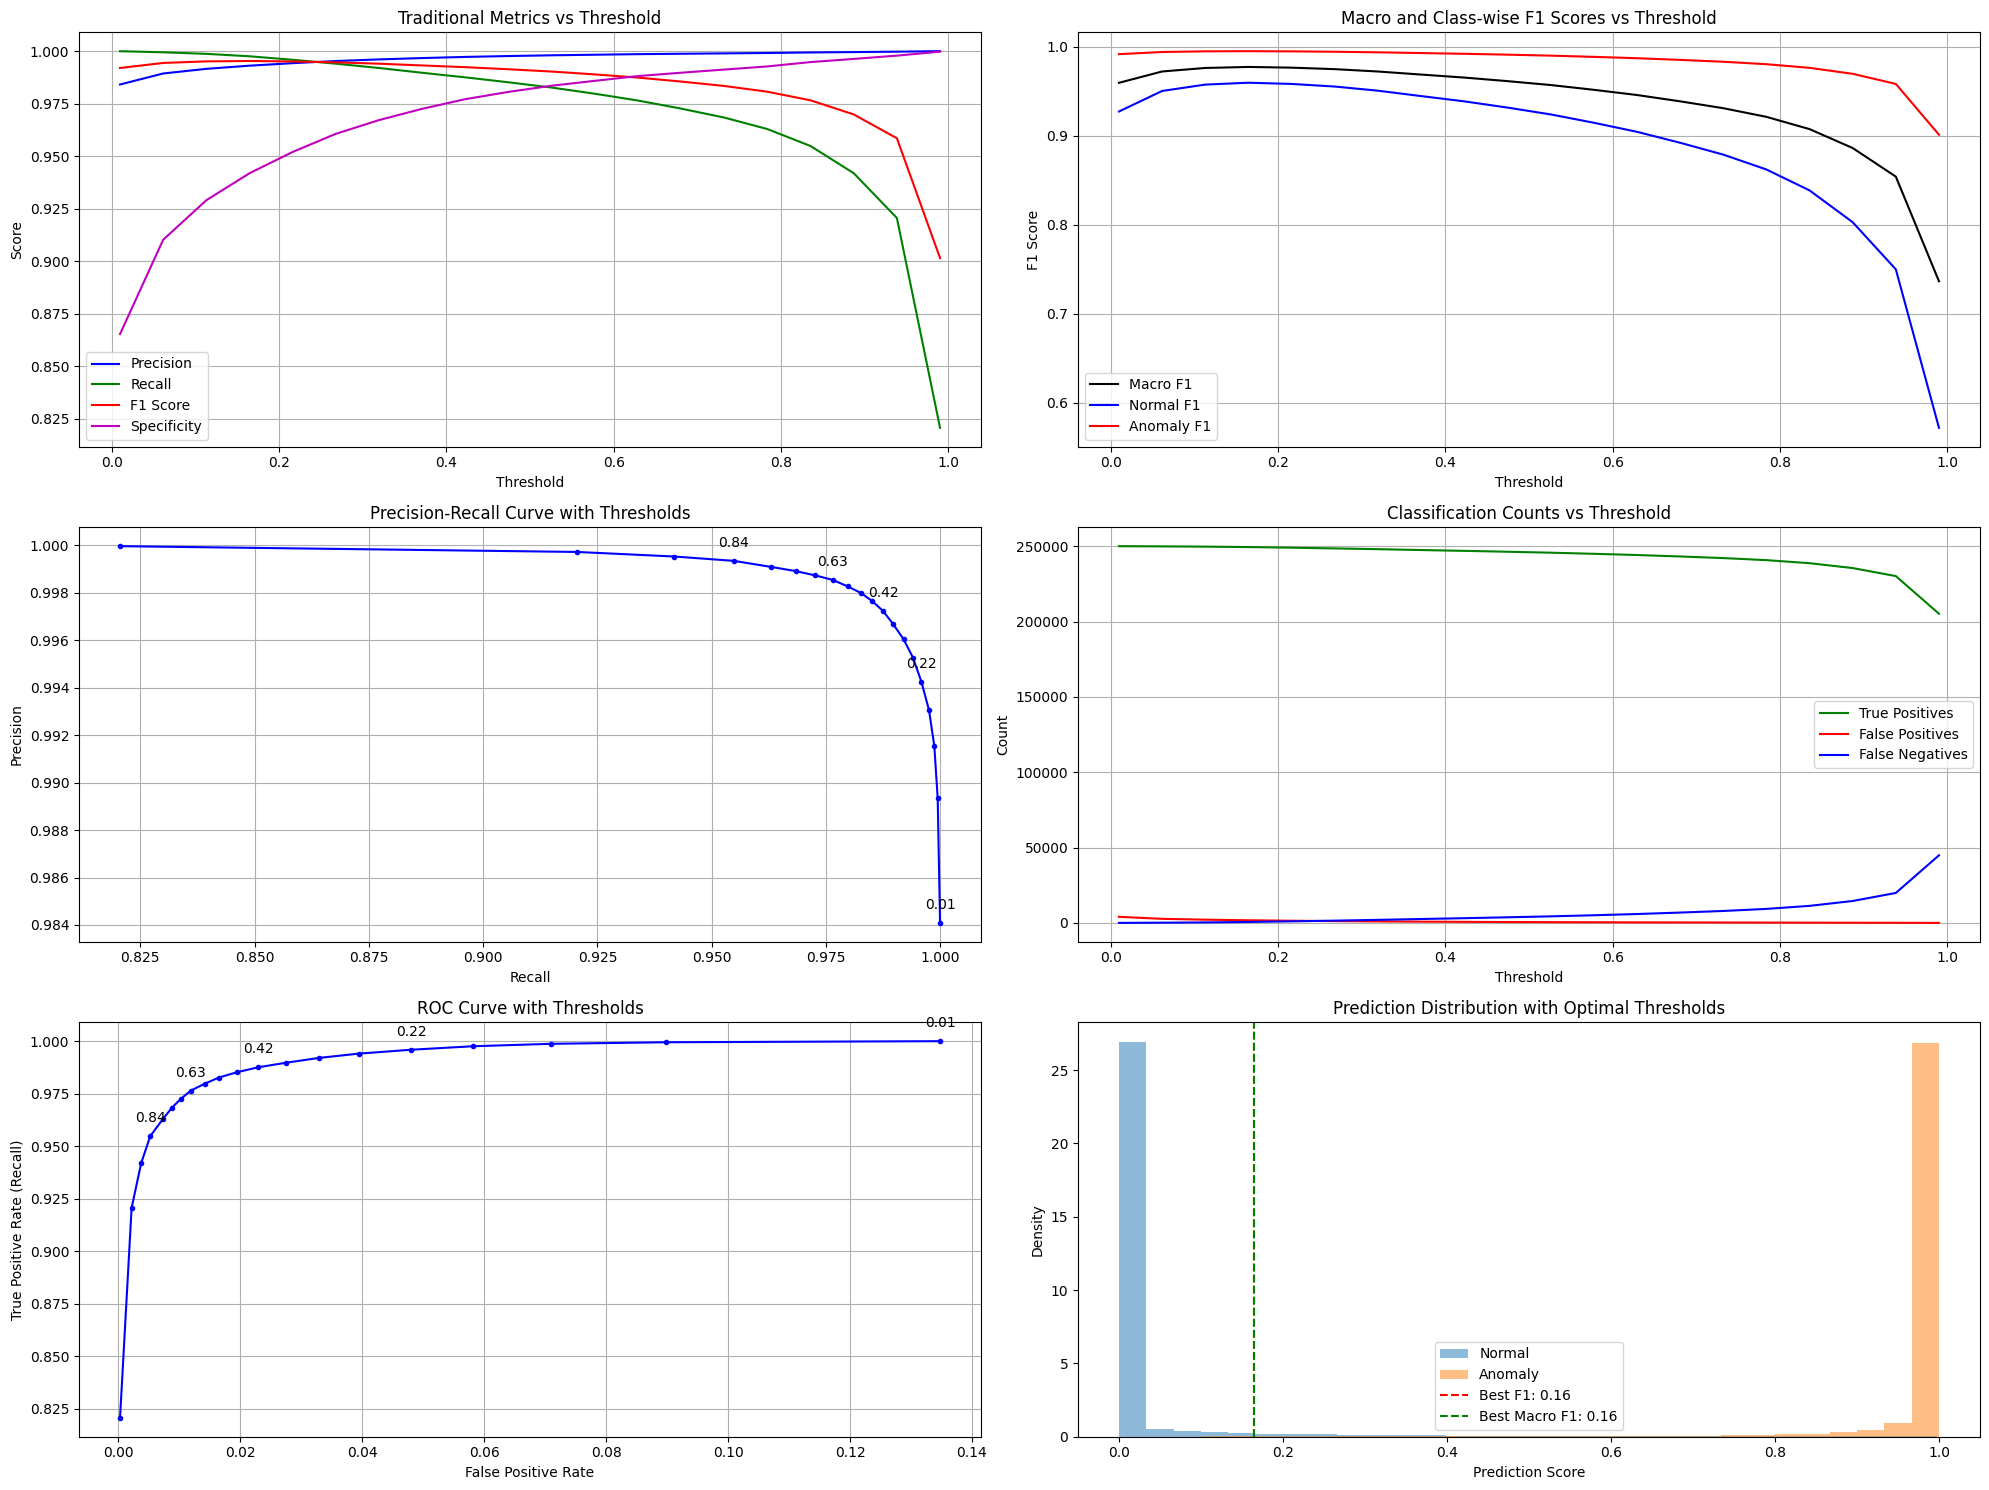

Optimal threshold (standard F1): 0.16 (F1: 0.9953)
Optimal threshold (macro F1): 0.16 (Macro F1: 0.9776)
  Class 0 (Normal) F1 at this threshold: 0.9598
  Class 1 (Anomaly) F1 at this threshold: 0.9953


In [102]:
best_threshold, threshold_results, _ = analyze_anomaly_thresholds(y_test, test_predictions)

In [ ]:

    # Plot metrics vs threshold
    plt.figure(figsize=(20, 15))
    
    # Traditional metrics
    plt.subplot(321)
    plt.plot(results_df['Threshold'], results_df['Precision'], 'b-', label='Precision')
    plt.plot(results_df['Threshold'], results_df['Recall'], 'g-', label='Recall')
    plt.plot(results_df['Threshold'], results_df['F1'], 'r-', label='F1 Score')
    plt.plot(results_df['Threshold'], results_df['Specificity'], 'm-', label='Specificity')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.title('Traditional Metrics vs Threshold')
    plt.legend()
    plt.grid(True)
    
    # Macro and class-wise F1 scores
    plt.subplot(322)
    plt.plot(results_df['Threshold'], results_df['Macro_F1'], 'k-', label='Macro F1')
    plt.plot(results_df['Threshold'], results_df['Normal_F1'], 'b-', label='Normal F1')
    plt.plot(results_df['Threshold'], results_df['Anomaly_F1'], 'r-', label='Anomaly F1')
    plt.xlabel('Threshold')
    plt.ylabel('F1 Score')
    plt.title('Macro and Class-wise F1 Scores vs Threshold')
    plt.legend()
    plt.grid(True)
    
    # Precision-Recall curve
    plt.subplot(323)
    plt.plot(results_df['Recall'], results_df['Precision'], 'b.-')
    # Annotate some points with threshold values
    for i in range(0, len(thresholds), len(thresholds)//5):
        plt.annotate(f"{thresholds[i]:.2f}", 
                   (results_df['Recall'].iloc[i], results_df['Precision'].iloc[i]),
                   textcoords="offset points", 
                   xytext=(0,10), 
                   ha='center')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve with Thresholds')
    plt.grid(True)
    
    # Classification counts
    plt.subplot(324)
    plt.plot(results_df['Threshold'], results_df['TP'], 'g-', label='True Positives')
    plt.plot(results_df['Threshold'], results_df['FP'], 'r-', label='False Positives')
    plt.plot(results_df['Threshold'], results_df['FN'], 'b-', label='False Negatives')
    plt.xlabel('Threshold')
    plt.ylabel('Count')
    plt.title('Classification Counts vs Threshold')
    plt.legend()
    plt.grid(True)
    
    # ROC curve
    plt.subplot(325)
    plt.plot(results_df['FPR'], results_df['Recall'], 'b.-')
    # Annotate some points with threshold values
    for i in range(0, len(thresholds), len(thresholds)//5):
        plt.annotate(f"{thresholds[i]:.2f}", 
                   (results_df['FPR'].iloc[i], results_df['Recall'].iloc[i]),
                   textcoords="offset points", 
                   xytext=(0,10), 
                   ha='center')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate (Recall)')
    plt.title('ROC Curve with Thresholds')
    plt.grid(True)
    
    # Prediction distribution
    plt.subplot(326)
    plt.hist(test_preds[y_test==0], bins=30, alpha=0.5, label='Normal', density=True)
    plt.hist(test_preds[y_test==1], bins=30, alpha=0.5, label='Anomaly', density=True)
    
    # Find both optimal thresholds
    best_f1_idx = results_df['F1'].idxmax()
    best_macro_f1_idx = results_df['Macro_F1'].idxmax()
    
    best_f1_threshold = results_df.loc[best_f1_idx, 'Threshold']
    best_macro_f1_threshold = results_df.loc[best_macro_f1_idx, 'Threshold']
    
    # Add vertical lines for optimal thresholds
    plt.axvline(x=best_f1_threshold, color='r', linestyle='--', 
                label=f'Best F1: {best_f1_threshold:.2f}')
    plt.axvline(x=best_macro_f1_threshold, color='g', linestyle='--', 
                label=f'Best Macro F1: {best_macro_f1_threshold:.2f}')
    
    plt.xlabel('Prediction Score')
    plt.ylabel('Density')
    plt.title('Prediction Distribution with Optimal Thresholds')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Find optimal threshold based on standard F1 score
    if results_df['F1'].max() > 0:
        best_idx = results_df['F1'].idxmax()
        best_threshold = results_df.loc[best_idx, 'Threshold']
        best_f1 = results_df.loc[best_idx, 'F1']
        print(f"Optimal threshold (standard F1): {best_threshold:.2f} (F1: {best_f1:.4f})")
    else:
        # If F1 is 0 for all thresholds, choose a conservative threshold
        best_threshold = 0.95
        print(f"All standard F1 scores are 0. Using conservative threshold: {best_threshold:.2f}")
    
    # Find optimal threshold based on macro F1 score
    if results_df['Macro_F1'].max() > 0:
        best_macro_idx = results_df['Macro_F1'].idxmax()
        best_macro_threshold = results_df.loc[best_macro_idx, 'Threshold']
        best_macro_f1 = results_df.loc[best_macro_idx, 'Macro_F1']
        print(f"Optimal threshold (macro F1): {best_macro_threshold:.2f} (Macro F1: {best_macro_f1:.4f})")
        
        # Show class-wise F1 scores at this threshold
        normal_f1 = results_df.loc[best_macro_idx, 'Normal_F1']
        anomaly_f1 = results_df.loc[best_macro_idx, 'Anomaly_F1']
        print(f"  Class 0 (Normal) F1 at this threshold: {normal_f1:.4f}")
        print(f"  Class 1 (Anomaly) F1 at this threshold: {anomaly_f1:.4f}")
    else:
        best_macro_threshold = best_threshold
        print(f"All macro F1 scores are 0. Using standard F1 threshold: {best_threshold:.2f}")
    
    # Return both thresholds and results
    return best_threshold, best_macro_threshold, results_df